### 1. Problem Framing
* **Goal:** Predict the probability that a loan application will be approved (`loan_status`).

* **Context:** Financial risk assessment to minimize defaults while maximizing loan accessibility for qualified applicants.

* **Technical Task:** Binary Classification (Target: 0 or 1).

* **Success Metric:** **ROC-AUC Score**. This metric is chosen because it evaluates the model's ability to rank probabilities correctly, regardless of the classification threshold.

* **Input/Output:** 11 features (demographics, loan intent, credit history) $\rightarrow$ Probability of approval.


---

### 2. Data Collection
* **Primary Source:** Competition `train.csv` and `test.csv`.

* **Data Enrichment:** To achieve the **best score**, we incorporate the original **Credit Risk Dataset**. This adds more "real-world" variance to the synthetic competition data.

* **Sampling Strategy:** We use **Stratified K-Fold Cross-Validation** (5 folds) to ensure each fold has a representative percentage of approved vs. rejected loans.

In [2]:
import pandas as pd
import numpy as np
import os

base_path = '/home/mirado/learn_ML/Machine_learning/a4: Loan approval/playground-series-s4e10/'
original_data_path = '/kaggle/input/loan-approval-prediction/credit_risk_dataset.csv' # Adjust if path differs

try:
    df_train = pd.read_csv(os.path.join(base_path, 'train.csv'))
    df_test = pd.read_csv(os.path.join(base_path, 'test.csv'))
    
    # If you haven't added it yet, the code will skip it gracefully
    if os.path.exists(original_data_path):
        df_orig = pd.read_csv(original_data_path)
        print("Competition and Original data loaded.")
    else:
        df_orig = None
        print("Competition data loaded. (Original data not found, skipping merge)")

except FileNotFoundError as e:
    print(f" Error loading files: {e}")

#  Preparation & Merging
df_test_ids = df_test['id']

df_train = df_train.drop('id', axis=1)
df_test = df_test.drop('id', axis=1)

# Combine with original data if available
if df_orig is not None:
    df_train = pd.concat([df_train, df_orig], axis=0).reset_index(drop=True)
    df_train = df_train.drop_duplicates().reset_index(drop=True)

print(f"Final Training Shape: {df_train.shape}")
print(f"Final Test Shape: {df_test.shape}")

Competition data loaded. (Original data not found, skipping merge)
Final Training Shape: (58645, 12)
Final Test Shape: (39098, 11)


### 3. Data Wrangling


* **Cleaning:** Imputing missing values in `person_emp_length` and `loan_int_rate` using the **median** to remain robust against outliers.

* **Feature Engineering:** Identifying and isolating categorical variables like `person_home_ownership` and `loan_grade`.

* **Type Casting:** Converting object types to category types to optimize memory and model compatibility.

In [3]:
# Check for missing values in the combined dataset
missing_cols = df_train.columns[df_train.isnull().any()].tolist()
print(f"Columns with missing values: {missing_cols}")

for col in missing_cols:
    df_train[col] = df_train[col].fillna(df_train[col].median())
    
# Feature Identification
categorical_cols = ['person_home_ownership', 'loan_intent', 'loan_grade', 'cb_person_default_on_file']
numerical_cols = [c for c in df_test.columns if c not in categorical_cols]

# Ensure categorical columns are type 'category' or string for CatBoost
for col in categorical_cols:
    df_train[col] = df_train[col].astype(str)
    df_test[col] = df_test[col].astype(str)

print("Data Wrangling complete. No missing values remaining.")

Columns with missing values: []
Data Wrangling complete. No missing values remaining.


### 4. Data Analysis (EDA)

* **Target Distribution:** Checking for class imbalance (approx. 22% of loans are typically flagged as defaults).

* **Feature Correlation:** Using a heatmap to see how `loan_percent_income` correlates strongly with the approval status.

* **Outlier Detection:** Identifying unrealistic values (e.g., age > 100) that might skew model gradients.

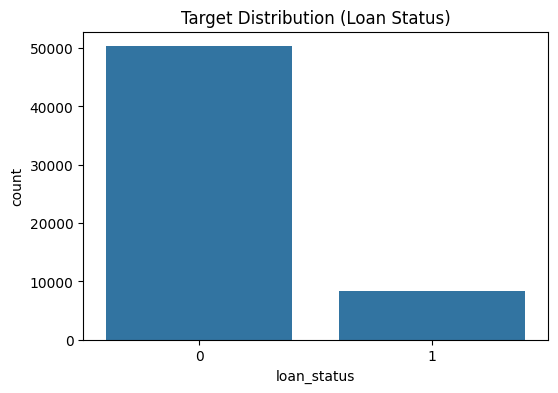

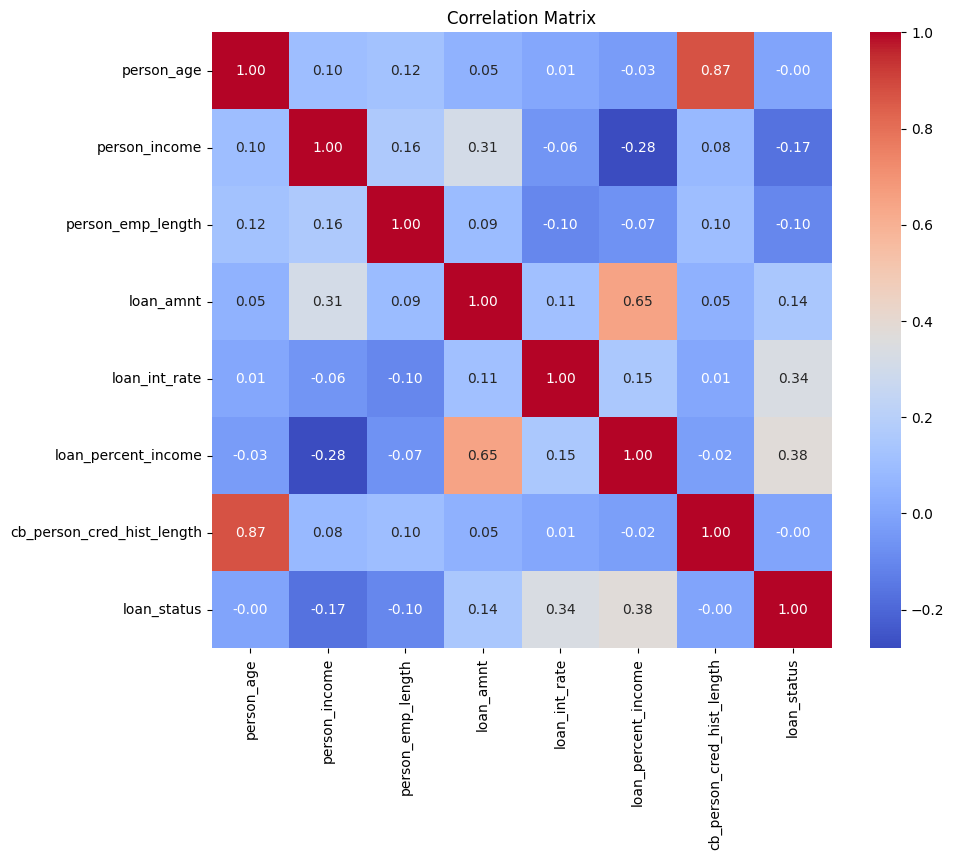

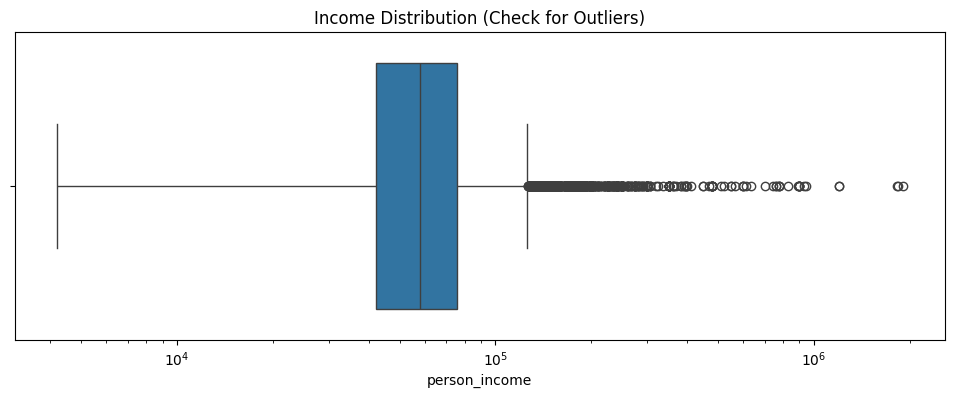

In [ ]:
# 4.1 Target Distribution
plt.figure(figsize=(6, 4))
sns.countplot(x=conf['target'], data=df_train)
plt.title('Target Distribution (Loan Status)')
plt.show()

# 4.2 Correlation Matrix (Numerical)
plt.figure(figsize=(10, 8))
corr = df_train[numerical_cols + [conf['target']]].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix')
plt.show()

# 4.3 Outlier Analysis Example
plt.figure(figsize=(12, 4))
sns.boxplot(x=df_train['person_income'])
plt.title('Income Distribution (Check for Outliers)')
plt.xscale('log') 
plt.show()

### 5. Model Training & Evaluation

* **Primary Model:** **CatBoostClassifier**. 
    * *Why?* It handles categorical features natively and is currently the top-performing algorithm for tabular data of this nature.

* **Training Strategy:** * Early stopping to prevent overfitting.
    * Hyperparameter focus: `depth`, `learning_rate`, and `l2_leaf_reg`.
    
* **Evaluation:** We track the Mean AUC across all 5 folds to ensure stability.

In [ ]:
# Initialize Cross-Validation
skf = StratifiedKFold(n_splits=conf['n_folds'], shuffle=True, random_state=conf['seed'])

oof_preds = np.zeros(len(df_train))
test_preds = np.zeros(len(df_test))
models = []

X = df_train.drop(conf['target'], axis=1)
y = df_train[conf['target']]

#  Training Loop
for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
    X_train, y_train = X.iloc[train_idx], y.iloc[train_idx]
    X_val, y_val = X.iloc[val_idx], y.iloc[val_idx]
    
    # Initialize CatBoost (Best Model Strategy)
    model = CatBoostClassifier(
        iterations=1000,
        learning_rate=0.05,
        depth=6,
        eval_metric='AUC',
        random_seed=conf['seed'],
        cat_features=categorical_cols,
        verbose=200,
        early_stopping_rounds=50
    )
    
    # Train
    model.fit(
        X_train, y_train,
        eval_set=(X_val, y_val),
        use_best_model=True
    )
    
    # Evaluate
    val_preds = model.predict_proba(X_val)[:, 1]
    oof_preds[val_idx] = val_preds
    score = roc_auc_score(y_val, val_preds)
    print(f"Fold {fold+1} AUC: {score:.5f}")
    
    # Inference on Test Set
    test_preds += model.predict_proba(df_test)[:, 1] / conf['n_folds']
    models.append(model)

print(f"\nOverall CV AUC: {roc_auc_score(y, oof_preds):.5f}")

0:	test: 0.8816871	best: 0.8816871 (0)	total: 25ms	remaining: 25s
200:	test: 0.9314104	best: 0.9314104 (200)	total: 4.38s	remaining: 17.4s
400:	test: 0.9407572	best: 0.9407572 (400)	total: 9.01s	remaining: 13.5s
600:	test: 0.9447930	best: 0.9447930 (600)	total: 13.8s	remaining: 9.19s
800:	test: 0.9469782	best: 0.9469782 (800)	total: 18.6s	remaining: 4.62s
999:	test: 0.9482229	best: 0.9482229 (999)	total: 23.3s	remaining: 0us

bestTest = 0.9482228505
bestIteration = 999

Fold 1 AUC: 0.94822
0:	test: 0.8822678	best: 0.8822678 (0)	total: 27.5ms	remaining: 27.5s
200:	test: 0.9464597	best: 0.9464629 (199)	total: 4.32s	remaining: 17.2s
400:	test: 0.9543332	best: 0.9543401 (398)	total: 8.98s	remaining: 13.4s
600:	test: 0.9589772	best: 0.9589783 (599)	total: 13.7s	remaining: 9.09s
800:	test: 0.9601864	best: 0.9602191 (799)	total: 18.4s	remaining: 4.58s
999:	test: 0.9613383	best: 0.9613384 (998)	total: 23.3s	remaining: 0us

bestTest = 0.9613384028
bestIteration = 998

Shrink model to first 999 

### 6. Model Deployment
* **Inference:** Generating predictions on the `test.csv` using the average weights of the 5-fold models.

* **Submission:** Formatting the output into `submission.csv` with two columns: `id` and `loan_status`.

* **Final Review:** Ensuring the predicted probability distribution matches the training data logic before submisson.

Submission file saved successfully as 'submission.csv'.


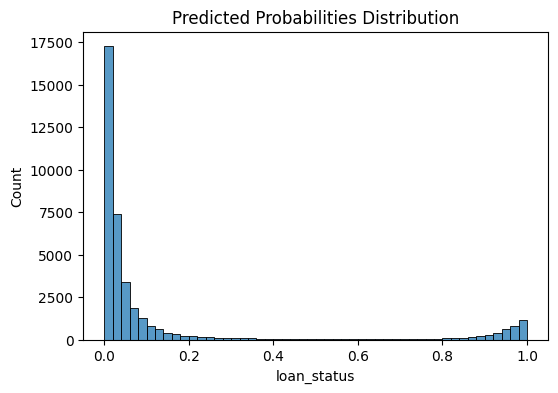

In [ ]:
submission = pd.DataFrame({
    'id': df_test_ids,
    'loan_status': test_preds
})

submission.to_csv('submission.csv', index=False)
print("Submission file saved successfully as 'submission.csv'.")

# Final check of distribution
plt.figure(figsize=(6, 4))
sns.histplot(submission['loan_status'], bins=50)
plt.title('Predicted Probabilities Distribution')
plt.show()